# Credit Score Classification

**Задача:** по имеющимся данным необходимо обучить модель, которая будет определять, к какому кредитному рейтингу отнести клиента банка (Poor, Standart, Good).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

import re 

from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.datasets import load_iris


In [2]:
from sklearn.experimental import enable_hist_gradient_boosting
from sklearn.ensemble import (
    BaggingClassifier,
    ExtraTreesClassifier,
    RandomForestClassifier,
    StackingClassifier,
    HistGradientBoostingClassifier
)
from xgboost import XGBClassifier
from sklearn.metrics import classification_report 
import joblib

c:\gitreg\srw\srwvenv\lib\site-packages\sklearn\experimental\enable_hist_gradient_boosting.py:19: UserWarning: Since version 1.0, it is not needed to import enable_hist_gradient_boosting anymore. HistGradientBoostingClassifier and HistGradientBoostingRegressor are now stable and can be normally imported from sklearn.ensemble.
  warnings.warn(


In [3]:
df = pd.read_csv('./data/train.csv')
# data_test = pd.read_csv('./data/test.csv') нет целевой переменной.

C:\Users\html2\AppData\Local\Temp\ipykernel_13108\2523424501.py:1: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('./data/train.csv')


In [4]:
df.sample(10)

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
90087,0x225d9,CUS_0xac2d,August,Jessicab,15,239-55-7534,Scientist,19243.32,1448.610000,6,...,Standard,1350.28,32.016906,11 Years and 6 Months,Yes,53.813878,126.24700615492254,!@9#%8,254.80011615309357,Standard
15645,0x71ab,CUS_0x3f18,June,Carolinez,41,309-95-7818,Scientist,30988.54,2827.378333,6,...,Standard,189.28,38.141073,13 Years and 9 Months,Yes,158.549241,191.3157483646331,Low_spent_Small_value_payments,222.87284363128768,Poor
59427,0x17235,CUS_0x3ec1,April,NaN,41,969-31-8219,Musician,70154.85,5696.237500,8,...,Standard,487.42,31.747179,20 Years and 11 Months,Yes,92.888270,157.34144483191812,!@9#%8,599.3940352286576,Standard
52127,0x1476d,CUS_0x41ea,August,Lindaz,41,733-38-8328,Teacher,37261.31_,2948.109167,5,...,Good,95.89,24.367149,19 Years and 10 Months,No,123.114072,114.61793580170065,High_spent_Small_value_payments,317.07890934645246,Good
29533,0xc30b,CUS_0x413,June,Alexei Oreskovicr,23,851-32-4418,Manager,41806.16,3564.846667,2,...,_,300.61,26.627676,26 Years and 7 Months,No,21.864682,114.94904937747768,High_spent_Small_value_payments,479.67093523253027,Standard
72488,0x1bebe,CUS_0x2e8d,January,Valentina Zaz,31,#F%$D@*&8,Manager,57396.72,5074.060000,3,...,_,351.72,33.196228,22 Years and 5 Months,No,61.010026,448.1938446536375,Low_spent_Medium_value_payments,278.20212889489846,Standard
65442,0x19574,CUS_0x7227,March,Protardf,50,338-77-4181,Writer,19519.66,1400.638333,3,...,Standard,529.09,23.881200,31 Years and 10 Months,Yes,45.557416,NaN,Low_spent_Small_value_payments,229.51630617680001,Standard
17598,0x7d1c,CUS_0x4434,July,McCoolo,30,949-12-7408,Scientist,7087.24,361.603333,8,...,Standard,54.25,27.885870,6 Years and 8 Months,Yes,22.301940,0.0,High_spent_Medium_value_payments,257.24565009468336,Standard
79617,0x1e883,CUS_0x9066,February,Chee Yinkal,50,958-05-0966,Musician,21761.49_,1615.457500,5,...,Standard,830.29,32.485175,15 Years and 2 Months,No,38.785619,124.270702858397,Low_spent_Medium_value_payments,278.48942821013486,Standard
89448,0x2221e,CUS_0x8b66,January,Szabos,30,454-08-3421,Doctor,39189.92,NaN,4,...,Standard,1365.66,22.173300,19 Years and 11 Months,Yes,24.005785,283.41610659350937,!@9#%8,267.5607750665737,Standard


In [5]:
df['Credit_Score'].value_counts()

Credit_Score
Standard    53174
Poor        28998
Good        17828
Name: count, dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              88592 non-null   ob

In [7]:
df.describe()

,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Delay_from_due_date,Num_Credit_Inquiries,Credit_Utilization_Ratio,Total_EMI_per_month
count,84998.000000,100000.000000,100000.00000,100000.000000,100000.000000,98035.000000,100000.000000,100000.000000
mean,4194.170850,17.091280,22.47443,72.466040,21.068780,27.754251,32.285173,1403.118217
std,3183.686167,117.404834,129.05741,466.422621,14.860104,193.177339,5.116875,8306.041270
min,303.645417,-1.000000,0.00000,1.000000,-5.000000,0.000000,20.000000,0.000000
25%,1625.568229,3.000000,4.00000,8.000000,10.000000,3.000000,28.052567,30.306660
50%,3093.745000,6.000000,5.00000,13.000000,18.000000,6.000000,32.305784,69.249473
75%,5957.448333,7.000000,7.00000,20.000000,28.000000,9.000000,36.496663,161.224249
max,15204.633333,1798.000000,1499.00000,5797.000000,67.000000,2597.000000,50.000000,82331.000000


In [8]:
df.describe(include=['object'])

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Num_of_Loan,Type_of_Loan,Num_of_Delayed_Payment,Changed_Credit_Limit,Credit_Mix,Outstanding_Debt,Credit_History_Age,Payment_of_Min_Amount,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
count,100000,100000,100000,90015,100000,100000,100000,100000,100000,88592,92998,100000,100000,100000,90970,100000,95521,100000,98800,100000
unique,100000,12500,8,10139,1788,12501,16,18940,434,6260,749,4384,4,13178,404,3,91049,7,98792,3
top,0x25fd5,CUS_0x942c,January,Stevex,38,#F%$D@*&8,_______,17273.83,3,Not Specified,19,_,Standard,1360.45,15 Years and 11 Months,Yes,__10000__,Low_spent_Small_value_payments,__-333333333333333333333333333__,Standard
freq,1,8,12500,44,2833,5572,7062,16,14386,1408,5327,2091,36479,24,446,52326,4305,25513,9,53174


Можно заметить что не все числовые признаки имеют тип int или float. Из этого можно сделать вывод, что не все данные в этих признаках числовые, следовательно их нужно изучить более подробно.

- **не нужные** - ID, Name, SSN
- **Категориальные** - Customer_ID, Month, Occupation, Type_of_Loan, Credit_Mix, Payment_of_Min_Amount, Payment_Behaviour
- **Числовые** - Age, Annual_Income, Monthly_Inhand_Salary, Num_Bank_Accounts, Num_Credit_Card, Interest_Rate, Num_of_Loan, Delay_from_due_date, Num_of_Delayed_Payment, Changed_Credit_Limit, Num_Credit_Inquiries, Outstanding_Debt, Credit_Utilization_Ratio, Credit_History_Age(FE), Total_EMI_per_month, Amount_invested_monthly, Monthly_Balance
- **Target** - Credit_Score

- Категориальные признаки

**Customer_ID**

In [9]:
df['Customer_ID'].value_counts()

Customer_ID
CUS_0x942c    8
CUS_0xd40     8
CUS_0x21b1    8
CUS_0x2dbc    8
CUS_0x1d18    8
             ..
CUS_0x4157    8
CUS_0x5407    8
CUS_0x284a    8
CUS_0x95ee    8
CUS_0x1cdb    8
Name: count, Length: 12500, dtype: int64

**Month**

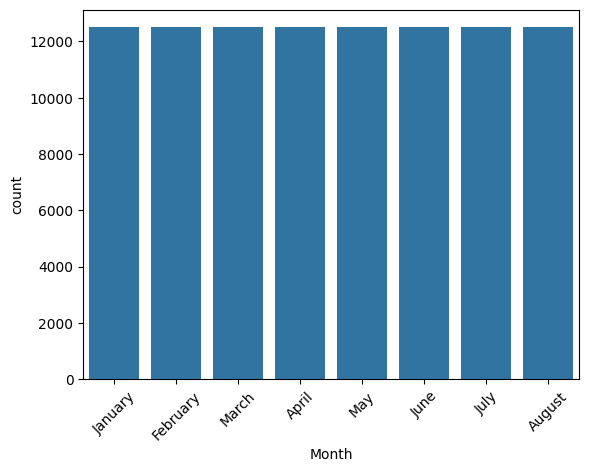

In [10]:
sns.countplot(x='Month', data=df);
plt.xticks(rotation=45);

**Occupation**

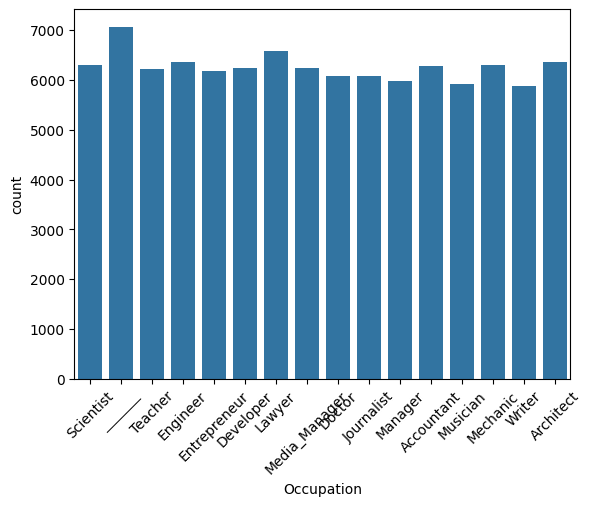

In [11]:
sns.countplot(x='Occupation', data=df);
plt.xticks(rotation=45);

**Type_of_Loan**

In [12]:
df['Type_of_Loan'].value_counts().head(15)

Type_of_Loan
Not Specified                             1408
Credit-Builder Loan                       1280
Personal Loan                             1272
Debt Consolidation Loan                   1264
Student Loan                              1240
Payday Loan                               1200
Mortgage Loan                             1176
Auto Loan                                 1152
Home Equity Loan                          1136
Personal Loan, and Student Loan            320
Not Specified, and Payday Loan             272
Mortgage Loan, and Home Equity Loan        264
Student Loan, and Payday Loan              256
Credit-Builder Loan, and Not Specified     248
Student Loan, and Credit-Builder Loan      248
Name: count, dtype: int64

После 9-го элемента начинаются повторы. Для того, чтобы модель лучше интерпретировала данные, можно из этого столбца сделать 8 новых (от Credit-Builder Loan до Home Equity Loan), в каждом из которых для каждого объекта указывать относится ли он к нему (True) или нет (False).

In [13]:
new_features_tol = df['Type_of_Loan'].value_counts().head(9).index[1:]

for x in new_features_tol:
    df[x] = df['Type_of_Loan'].str.contains(x)

df.drop('Type_of_Loan', axis=1, inplace=True)

**Payment_of_Min_Amount**

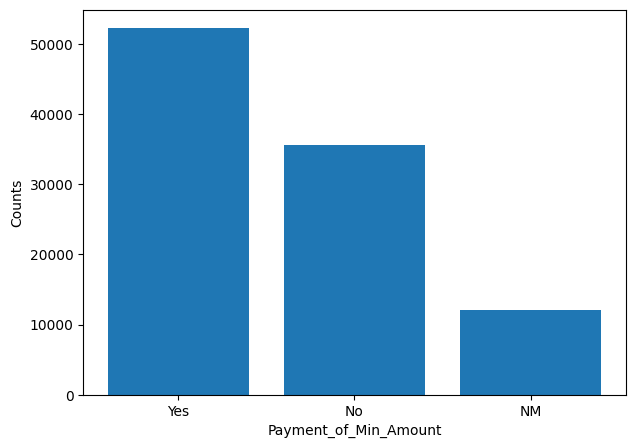

In [14]:
payment_of_Min_Amount_vc = df['Payment_of_Min_Amount'].value_counts()

plt.figure(figsize=(7, 5))

plt.bar(payment_of_Min_Amount_vc.index, payment_of_Min_Amount_vc.values)
plt.xlabel("Payment_of_Min_Amount")
plt.ylabel("Counts")

plt.show()

**Credit_Mix**

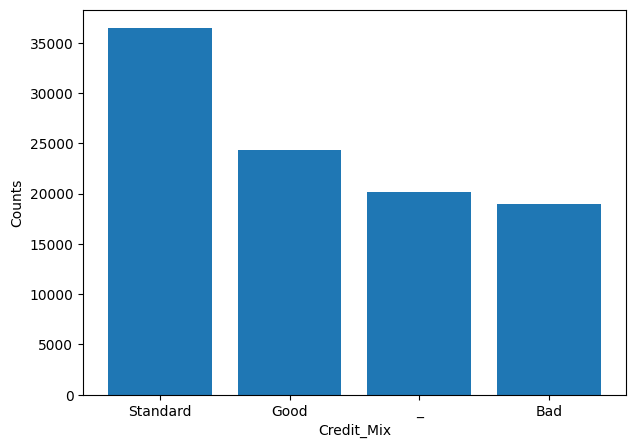

In [15]:
credit_mix_vc = df['Credit_Mix'].value_counts()

plt.figure(figsize=(7, 5))

plt.bar(credit_mix_vc.index, credit_mix_vc.values)
plt.xlabel("Credit_Mix")
plt.ylabel("Counts")

plt.show()

**Payment_Behaviour**

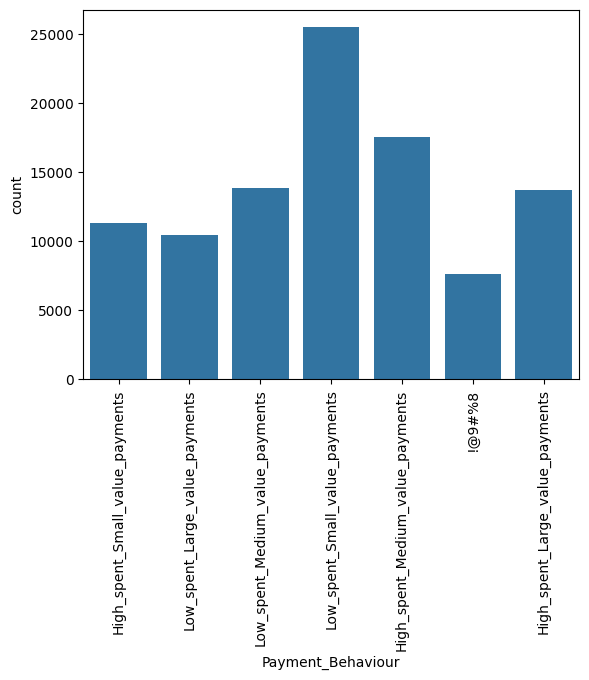

In [16]:
sns.countplot(x='Payment_Behaviour', data=df);
plt.xticks(rotation=90);

- Числовые признаки

**Age** (*)

In [17]:
df['Age'].unique()[:50]

array(['23', '-500', '28_', '28', '34', '54', '55', '21', '31', '33',
       '34_', '7580', '30', '30_', '24', '24_', '44', '45', '40', '41',
       '32', '33_', '35', '35_', '36', '39', '37', '181', '20', '46',
       '26', '42', '19', '31_', '48', '995', '40_', '37_', '38', '54_',
       '5079', '43', '21_', '22', '6409', '16', '7080', '18', '849',
       '3885'], dtype=object)

**Annual income** (*)

In [18]:
df['Annual_Income'].unique()

array(['19114.12', '34847.84', '34847.84_', ..., '20002.88', '39628.99',
       '39628.99_'], dtype=object)

**Monthly inhand salary**

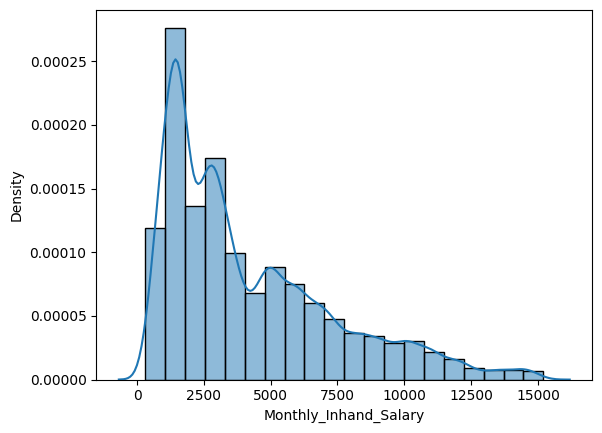

In [19]:
sns.histplot(df['Monthly_Inhand_Salary'], bins=20, kde=True, stat='density', kde_kws=dict(cut=3))
pass

In [20]:
df.loc[df.Monthly_Inhand_Salary < 0, 'Monthly_Inhand_Salary']

Series([], Name: Monthly_Inhand_Salary, dtype: float64)

**Num_Bank_Accounts** 

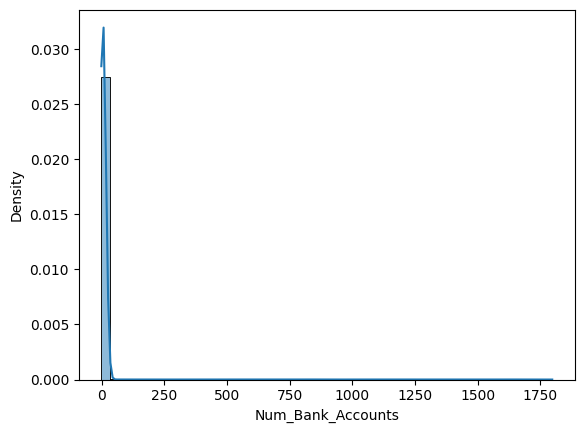

In [21]:
sns.histplot(df['Num_Bank_Accounts'], bins=50, kde=True, stat='density')
pass

In [22]:
df.loc[df.Num_Bank_Accounts < 0, 'Num_Bank_Accounts']

30330   -1
30331   -1
30332   -1
30333   -1
30334   -1
30335   -1
43689   -1
43690   -1
43691   -1
43692   -1
43693   -1
43694   -1
43695   -1
47212   -1
47213   -1
47214   -1
47215   -1
55636   -1
55637   -1
55638   -1
55639   -1
Name: Num_Bank_Accounts, dtype: int64

**Num_Credit_Card**

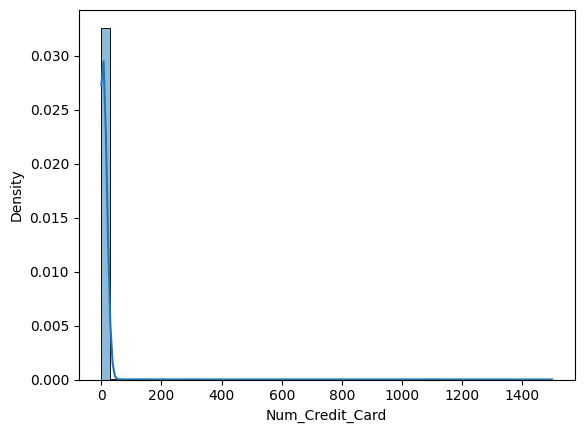

In [23]:
sns.histplot(df['Num_Credit_Card'], bins= 50, kde=True, stat='density')
pass

In [24]:
df.loc[df.Num_Credit_Card < 0, 'Num_Credit_Card']

Series([], Name: Num_Credit_Card, dtype: int64)

**Interest Rate**

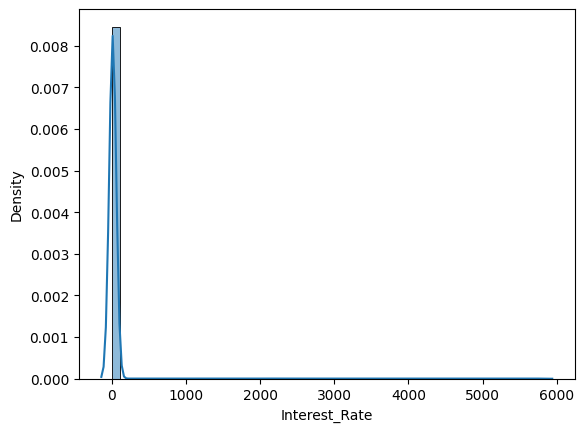

In [25]:
sns.histplot(df['Interest_Rate'], bins=50, kde=True, stat='density', kde_kws=dict(cut=3))
pass

In [26]:
df.loc[df.Interest_Rate > 30, 'Interest_Rate']

44       5318
89        433
104        32
105        32
106        32
         ... 
99838      32
99839      32
99882    1947
99914     360
99997    5729
Name: Interest_Rate, Length: 8202, dtype: int64

**Num_of_Loan** (*)

In [27]:
df['Num_of_Loan'].unique()[:10]

array(['4', '1', '3', '967', '-100', '0', '0_', '2', '3_', '2_'],
      dtype=object)

**Delay_from_due_date**

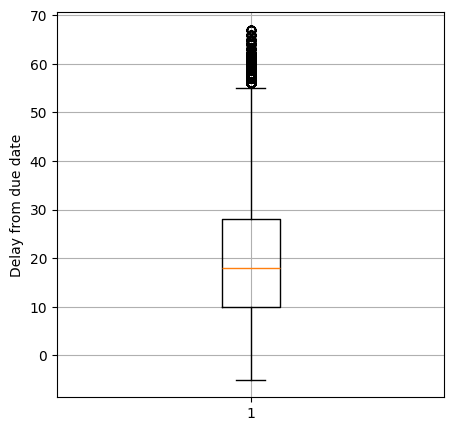

In [28]:
# sns.histplot(df['Delay_from_due_date'], bins=20, kde=True, stat='density', kde_kws=dict(cut=3))
# pass
# sns.boxplot(df['Delay_from_due_date'])
plt.figure(figsize=(5, 5))
plt.boxplot(df['Delay_from_due_date'])
plt.ylabel('Delay from due date')
plt.grid()
plt.show()

**Num_of_Delayed_Payment** (*)

In [29]:
df['Num_of_Delayed_Payment'].unique()[:10]

array(['7', nan, '4', '8_', '6', '1', '-1', '3_', '0', '8'], dtype=object)

**Changed_Credit_Limit** (*)

df['Changed_Credit_Limit'].value_counts()

In [30]:
df['Changed_Credit_Limit'].unique()

array(['11.27', '_', '6.27', ..., '17.509999999999998', '25.16', '21.17'],
      dtype=object)

**Num_Credit_Inquiries**

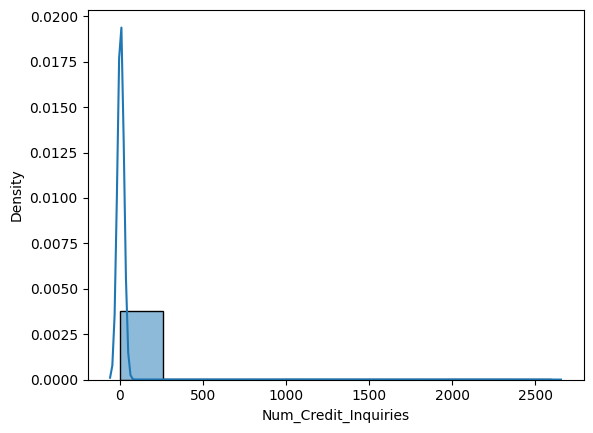

In [31]:
sns.histplot(df['Num_Credit_Inquiries'], bins=10, kde=True, stat='density', kde_kws=dict(cut=3))
pass

**Outstanding_Debt** (*)

In [32]:
df['Outstanding_Debt'].unique()[:50]

array(['809.98', '605.03', '1303.01', '632.46', '943.86', '548.2',
       '352.16', '1704.18', '1377.74', '421.43', '1328.93', '1328.93_',
       '950.36', '179.22', '2602.69', '758.44', '818.22', '1296.64',
       '1283.37', '1283.37_', '107.41', '2430.21', '881.4', '1672.43',
       '76.23', '569.8', '3532.83', '614.6', '2686.81', '1233.1',
       '400.07', '2258.73', '413.32', '1793.54', '1489.49', '98.97',
       '556.91', '1293.02', '3421.66', '1173.7', '1693.95', '233.79',
       '602.5', '3470.08', '749.95', '949.38', '1095.73', '3422.49',
       '2797.17_', '2797.17'], dtype=object)

**Credit_Utilization_Ratio**

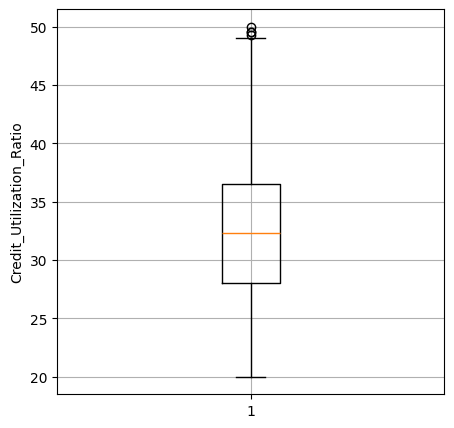

In [33]:
plt.figure(figsize=(5, 5))
plt.boxplot(df['Credit_Utilization_Ratio'])
plt.ylabel('Credit_Utilization_Ratio')
plt.grid()
plt.show()

**Credit_History_Age**

In [34]:
df['Credit_History_Age']

0         22 Years and 1 Months
1                           NaN
2         22 Years and 3 Months
3         22 Years and 4 Months
4         22 Years and 5 Months
                  ...          
99995     31 Years and 6 Months
99996     31 Years and 7 Months
99997     31 Years and 8 Months
99998     31 Years and 9 Months
99999    31 Years and 10 Months
Name: Credit_History_Age, Length: 100000, dtype: object

**Total_EMI_per_month**

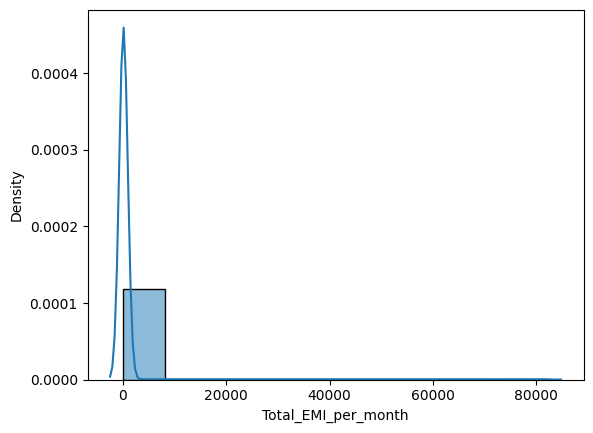

In [35]:
sns.histplot(df['Total_EMI_per_month'], bins=10, kde=True, stat='density', kde_kws=dict(cut=3))
pass

**Amount_invested_monthly** (*)

In [36]:
df['Amount_invested_monthly'].unique()[:50]

array(['80.41529543900253', '118.28022162236736', '81.699521264648',
       '199.4580743910713', '41.420153086217326', '62.430172331195294',
       '178.3440674122349', '24.785216509052056', '104.291825168246',
       '40.39123782853101', '58.51597569589465', '99.30622796053305',
       '130.11542024292334', '43.477190144355745', '70.10177420755677',
       '218.90434353388733', '168.413702679309', '232.86038375993544',
       '__10000__', '825.2162699393922', '430.9475278803298',
       '257.80809942568976', '263.17416316163934', '81.22885871073616',
       '124.88181990234848', '83.40650880252501', '272.3340373956682',
       '84.95284817115969', '71.28367488286933', '125.61725053231268',
       '276.72539431736266', '74.44364104999623', '173.13865100158367',
       '96.78548508587444', '62.72327834435009', '37.64363788963997',
       '181.0119827315892', '181.33090096186916', '98.67440994166124',
       '172.93921446875606', '150.05973429800815', '618.2023912505837',
       '177.951

**Monthly_Balance** (*)

In [37]:
try:
    df['Monthly_Balance'].astype('float64')
except:
    print('There are no numbers here')

There are no numbers here


Данные имеют некоторые проблемы:
1) Occupation, Credit Mix имеют "___"
2) У признака Payment_Behaviour есть непонятное значение "!@9#%8"
3) Признаки Age, Annual income, Num_of_Loan, Num_of_Delayed_Payment, Changed_Credit_Limit, Outstanding_Debt, Amount_invested_monthly, Monthly_Balance по факту являются числовыми, но из-за "мусорных" значений (часто могут встретиться числа с минусами или нижние подчеркивания), имеют тип object. Будем считать, что это просто ошибки ввода, и уберем из чисел лишние символы.
4) У Num_Bank_Accounts есть отрицательные значения.
5) Num_Bank_Accounts, Num_Credit_Card, Interest Rate, Delay_from_due_date, Num_Credit_Inquiries, Credit_Utilization_Ratio, Total_EMI_per_month имеют выбросы.
6) Credit_History_Age лучше перевести в числовой признак.
7) Много пропущенных данных
8) Целевой признак (Credit_Score) имеет отношение порядка, но является категориальным признаком. Лучше изменить его на 0, 1, 2.

### Preprocesing

#### Data cleaning

**Credit_Mix**

In [38]:
mapa = {
    'Bad': 0,
    'Standard' : 1,
    'Good' : 2,
    '_' : np.nan
}
df['Credit_Mix'] = df['Credit_Mix'].map(mapa)

**Occupation**

In [39]:
df['Occupation'].value_counts()

Occupation
_______          7062
Lawyer           6575
Architect        6355
Engineer         6350
Scientist        6299
Mechanic         6291
Accountant       6271
Developer        6235
Media_Manager    6232
Teacher          6215
Entrepreneur     6174
Doctor           6087
Journalist       6085
Manager          5973
Musician         5911
Writer           5885
Name: count, dtype: int64

"_______" встречается довольно часто, поэтому лучше не заменять ее на моду, так как это может исказить распределение. 

In [40]:
df['Occupation'] = df['Occupation'].replace('_______', 'Unknown')

**Payment_Behaviour**

In [41]:
mode_pb = df['Payment_Behaviour'].mode()[0]
df['Payment_Behaviour'] = df['Payment_Behaviour'].replace('!@9#%8', mode_pb)

**Credit_History_Age**

In [42]:
df['Credit_History_Age']

0         22 Years and 1 Months
1                           NaN
2         22 Years and 3 Months
3         22 Years and 4 Months
4         22 Years and 5 Months
                  ...          
99995     31 Years and 6 Months
99996     31 Years and 7 Months
99997     31 Years and 8 Months
99998     31 Years and 9 Months
99999    31 Years and 10 Months
Name: Credit_History_Age, Length: 100000, dtype: object

In [43]:
def History_age(age):
    try : 
        years = int("".join(re.findall('[0-9]',''.join(age.split("and")[0]))))
        month = int("".join(re.findall('[0-9]',''.join(age.split("and")[1]))))
        return years*12 + month
    except :
        return np.nan

In [44]:
df['Credit_History_Age'] = df['Credit_History_Age'].apply(History_age)

**Числовые признаки с типом object** 

In [45]:
N_to_fix = ['Age', 'Annual_Income', 'Num_of_Loan',
            'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Amount_invested_monthly',
            'Outstanding_Debt' , 'Monthly_Balance']


Уберем лишние символы "_" из столбцов **N_to_fix**

In [46]:
def fix_nums(num):
    try : 
        return float(num.replace("_",""))
    except :
        return np.nan

In [47]:
for col in N_to_fix :
    df[col] = df[col].apply(fix_nums)

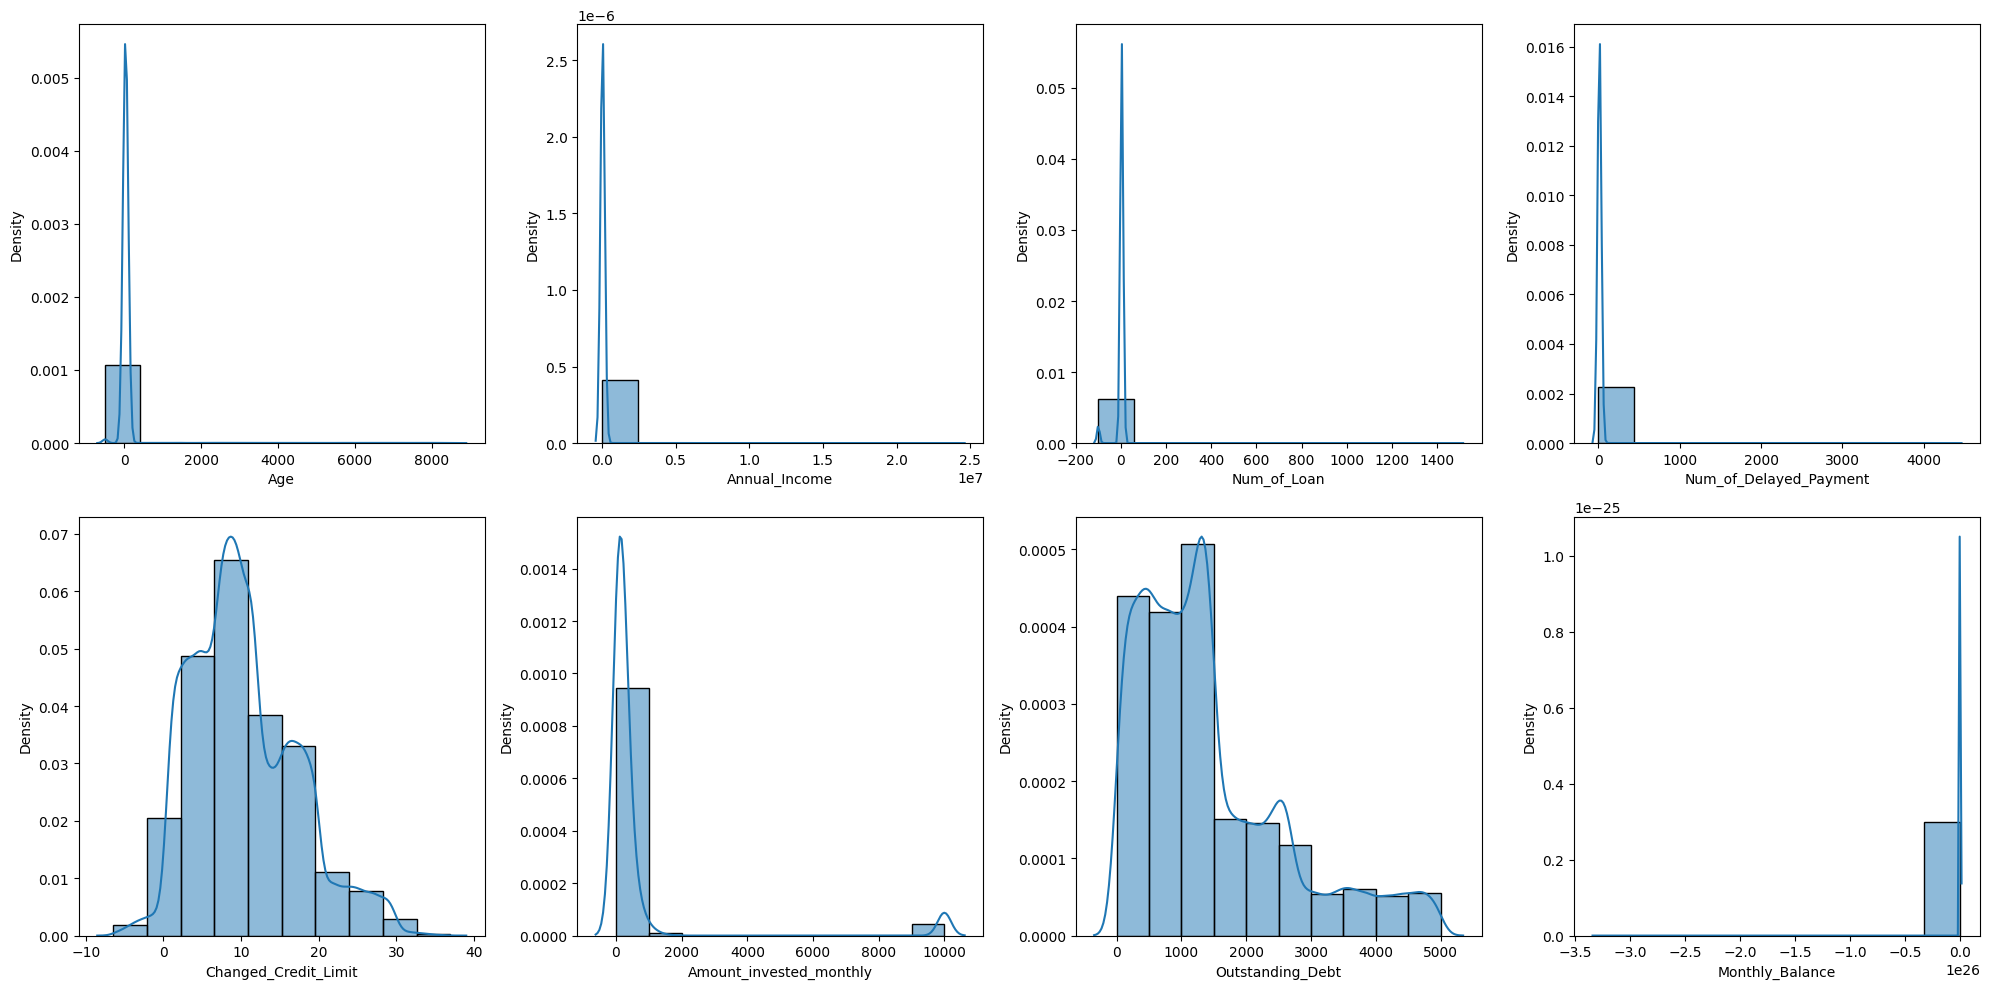

In [48]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(N_to_fix):
    sns.histplot(df[col], bins=10, kde=True, stat='density',
                 kde_kws=dict(cut=3), ax=axes[i])
    # axes[i].set_title(col)

plt.tight_layout()


- Age

In [49]:
df.loc[df['Age'] < 0, 'Age'] = np.nan
df.loc[df['Age'] > 100, 'Age'] = np.nan


In [50]:
med_age = df['Age'].median()
mean_age = df['Age'].mean()
display(med_age, mean_age)

np.float64(33.0)

np.float64(33.32327408870238)

In [51]:
df['Age'].isna().sum()

np.int64(2776)

In [52]:
df['Age'] = df['Age'].fillna(med_age)

- Num_of_Loan

In [53]:
df.loc[df['Num_of_Loan'] < 0] = np.nan

#### Обработка пропущенных значений

<BarContainer object of 35 artists>

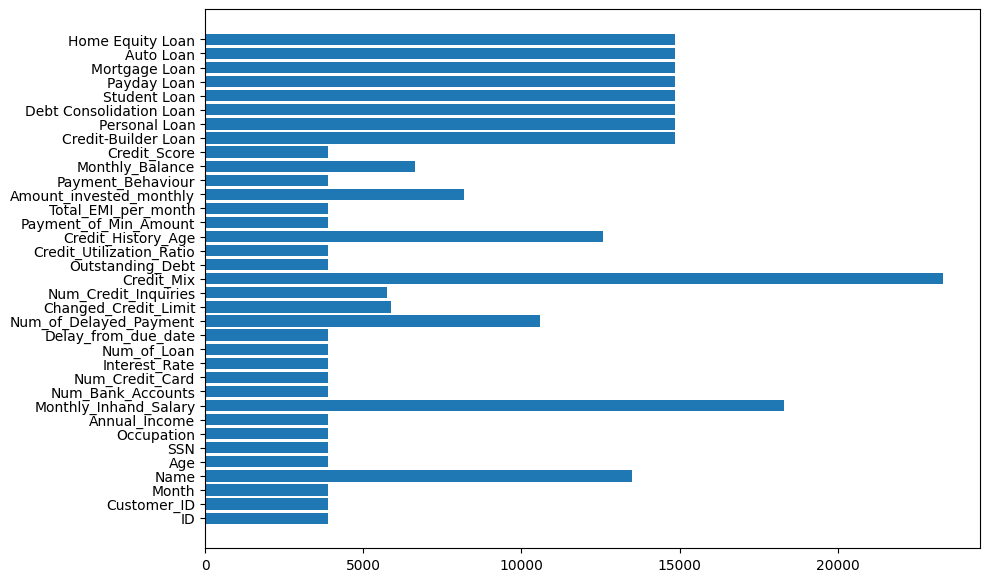

In [54]:
missed_data = df.isna().sum(axis=0)

plt.figure(figsize=(10,7))

plt.barh(missed_data.index, missed_data.values)

In [55]:
mas = ['Credit-Builder Loan', 'Personal Loan', 'Debt Consolidation Loan', 'Student Loan',
        'Payday Loan', 'Mortgage Loan', 'Auto Loan', 'Home Equity Loan']
for x in mas:
    df[x] = df[x].fillna(0)
    df[x] = df[x].astype(int)

In [56]:
mode_cs = df['Credit_Score'].mode()[0]
mode_month = df['Month'].mode()[0]
mode_occupation = df['Occupation'].mode()[0]

df['Month'] = df['Month'].fillna(mode_month)
df['Occupation'] = df['Occupation'].fillna(mode_occupation)
df['Credit_Score'] = df['Credit_Score'].fillna(mode_cs)

In [57]:
df.fillna(df.median(axis=0, numeric_only=True), inplace=True)

In [58]:
df.loc[df['Payment_of_Min_Amount'] == 'NM', 'Payment_of_Min_Amount'] = 'No'
mode_poma = df['Payment_of_Min_Amount'].mode()[0]
df['Payment_of_Min_Amount'] = df['Payment_of_Min_Amount'].fillna(mode_poma)

In [59]:
df['Payment_Behaviour'] = df['Payment_Behaviour'].fillna(df['Payment_Behaviour'].mode()[0])


In [60]:
df.drop(['ID', 'Customer_ID', 'Name', 'SSN'], axis=1,inplace=True)

In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Month                     100000 non-null  object 
 1   Age                       100000 non-null  float64
 2   Occupation                100000 non-null  object 
 3   Annual_Income             100000 non-null  float64
 4   Monthly_Inhand_Salary     100000 non-null  float64
 5   Num_Bank_Accounts         100000 non-null  float64
 6   Num_Credit_Card           100000 non-null  float64
 7   Interest_Rate             100000 non-null  float64
 8   Num_of_Loan               100000 non-null  float64
 9   Delay_from_due_date       100000 non-null  float64
 10  Num_of_Delayed_Payment    100000 non-null  float64
 11  Changed_Credit_Limit      100000 non-null  float64
 12  Num_Credit_Inquiries      100000 non-null  float64
 13  Credit_Mix                100000 non-null  fl

In [62]:
mapa2 = {
    'Poor' : 0,
    'Standard' : 1,
    'Good' : 2
}
df['Credit_Score'] = df['Credit_Score'].map(mapa2)

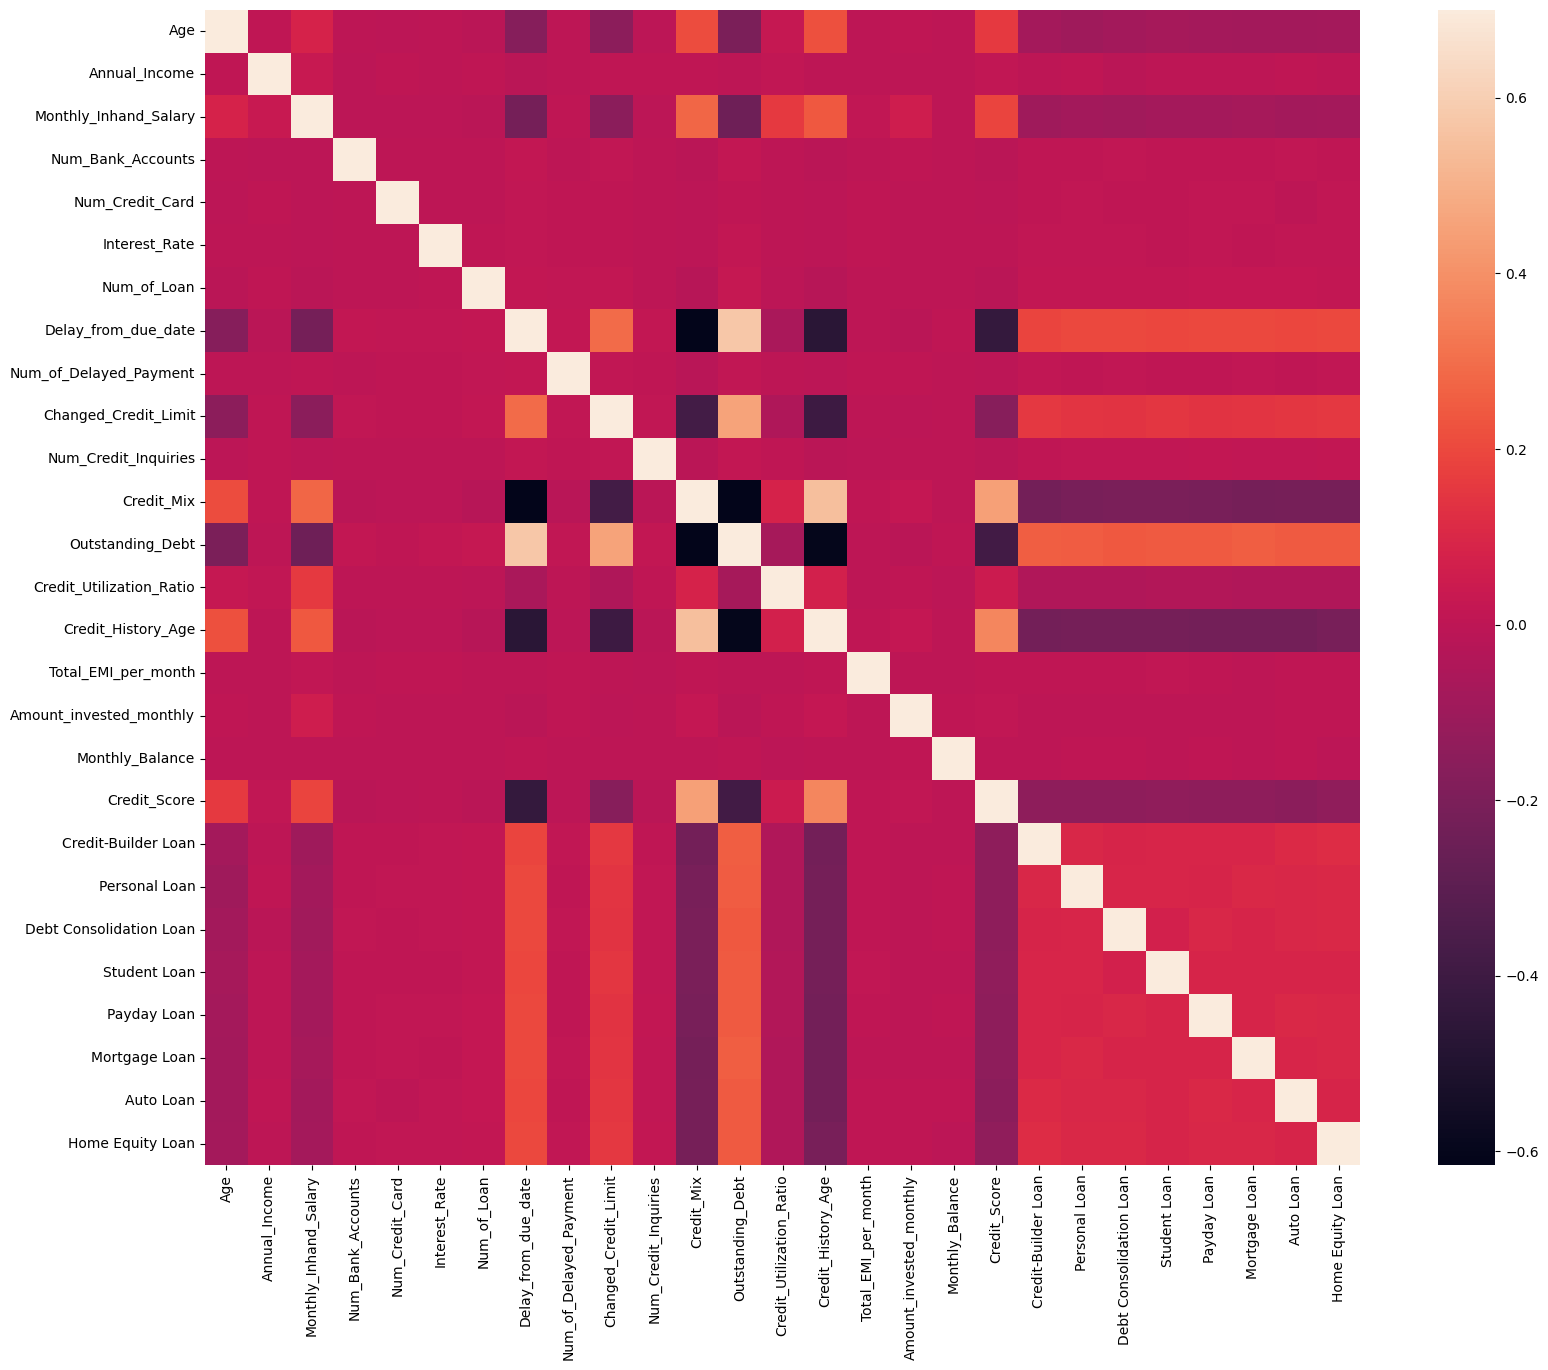

In [63]:
corrmat = df.corr(numeric_only=True)
f, ax = plt.subplots(figsize=(20, 15))
sns.heatmap(corrmat, vmax=.7, square=True);

In [64]:
a = corrmat.apply(lambda x: (x > 0.6) | (x < -0.6))
a.iloc[1]
lst = [
    (col, indx)
    for indx in a.index
    for col, val in a.loc[indx].items()
    if val and col != indx
]
lst


[('Credit_Mix', 'Delay_from_due_date'),
 ('Delay_from_due_date', 'Credit_Mix'),
 ('Outstanding_Debt', 'Credit_Mix'),
 ('Credit_Mix', 'Outstanding_Debt'),
 ('Credit_History_Age', 'Outstanding_Debt'),
 ('Outstanding_Debt', 'Credit_History_Age')]

In [65]:
corrmat.shape

(27, 27)

#### One Hot encoding

In [66]:
unprocessed_cat_features = df.select_dtypes(include=[object]).columns.tolist()
unprocessed_cat_features

['Month', 'Occupation', 'Payment_of_Min_Amount', 'Payment_Behaviour']

In [67]:
encoder = OneHotEncoder(sparse_output=False)
one_hot_encoded = encoder.fit_transform(df[unprocessed_cat_features])
one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(unprocessed_cat_features), index=df.index)



In [68]:
one_hot_df

,Month_April,Month_August,Month_February,Month_January,Month_July,Month_June,Month_March,Month_May,Occupation_Accountant,Occupation_Architect,...,Occupation_Unknown,Occupation_Writer,Payment_of_Min_Amount_No,Payment_of_Min_Amount_Yes,Payment_Behaviour_High_spent_Large_value_payments,Payment_Behaviour_High_spent_Medium_value_payments,Payment_Behaviour_High_spent_Small_value_payments,Payment_Behaviour_Low_spent_Large_value_payments,Payment_Behaviour_Low_spent_Medium_value_payments,Payment_Behaviour_Low_spent_Small_value_payments
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
99996,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
99997,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
99998,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [69]:
df = pd.concat([df, one_hot_df], axis=1)
df = df.drop(unprocessed_cat_features, axis=1)


In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 59 columns):
 #   Column                                              Non-Null Count   Dtype  
---  ------                                              --------------   -----  
 0   Age                                                 100000 non-null  float64
 1   Annual_Income                                       100000 non-null  float64
 2   Monthly_Inhand_Salary                               100000 non-null  float64
 3   Num_Bank_Accounts                                   100000 non-null  float64
 4   Num_Credit_Card                                     100000 non-null  float64
 5   Interest_Rate                                       100000 non-null  float64
 6   Num_of_Loan                                         100000 non-null  float64
 7   Delay_from_due_date                                 100000 non-null  float64
 8   Num_of_Delayed_Payment                              100000 non-nu

#### Подготовка данных для обучения модели

In [71]:
X = df.drop(columns=['Credit_Score'])
y = df['Credit_Score']

In [72]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, shuffle=True)

In [73]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [74]:
X_train.shape

(75000, 58)

### Обучение моделей

In [75]:
model1 = LogisticRegression()
model1.fit(X_train_scaled, y_train)
y_pred1 = model1.predict(X_test_scaled)

In [76]:
accuracy = accuracy_score(y_test, y_pred1)
accuracy 


0.6258

In [77]:
model3 = LogisticRegression()
model3.fit(X_train, y_train)
y_pred3 = model3.predict(X_test)
accuracy = accuracy_score(y_test, y_pred3)
accuracy 

0.17092

In [ ]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=750, solver='saga'))
])
param_grid = {
    'logreg__C': [0.01, 0.1, 1, 10],
    'logreg__penalty': ['l1', 'l2', 'elasticnet'],
    'logreg__l1_ratio': [0.1, 0.5, 0.9],
    'logreg__class_weight': [None, 'balanced']
}
grid = GridSearchCV(pipe, param_grid, cv=4, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)
print("Лучшие параметры:", grid.best_params_)
print("Лучшая accuracy:", grid.best_score_)


In [79]:
bagging = BaggingClassifier(n_jobs=-1)
extraTrees = ExtraTreesClassifier(max_depth=10, n_jobs=-1)
randomForest = RandomForestClassifier(n_jobs=-1)
histGradientBoosting = HistGradientBoostingClassifier()
XGB = XGBClassifier(n_jobs=-1)

model = StackingClassifier([
    ('bagging', bagging),
    ('extraTress', extraTrees),
    ('randomforest', randomForest),
    ('histGradientBoosting', histGradientBoosting),
    ('XGB', XGB)
], n_jobs=-1)

In [80]:
model.fit(X_train, y_train)

StackingClassifier(estimators=[('bagging', BaggingClassifier(n_jobs=-1)),
                               ('extraTress',
                                ExtraTreesClassifier(max_depth=10, n_jobs=-1)),
                               ('randomforest',
                                RandomForestClassifier(n_jobs=-1)),
                               ('histGradientBoosting',
                                HistGradientBoostingClassifier()),
                               ('XGB',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None...
                                              grow_policy=None,
                                              importance_type=None,
                                              interaction_constraints=None,
                                              learning_rate=None, max_bin=None,
                                              max_cat_threshold=None,
                                              max_cat_to_onehot=None,
                                              max_delta_step=None,
                                              max_depth=None, max_leaves=None,
                                              min_child_weight=None,
                                              missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=None, n_jobs=-1,
                                              num_parallel_tree=None,
                                              random_state=None, ...))],
                   n_jobs=-1)

In [81]:
print("Train Score: ",model.score(X_train, y_train))

Train Score:  0.9998133333333333


In [82]:
print("Test Score: ",model.score(X_test, y_test))

Test Score:  0.7976


In [83]:
y_pred = model.predict(X_test)

In [84]:
print(classification_report(y_pred,y_test))


              precision    recall  f1-score   support

           0       0.78      0.80      0.79      6976
           1       0.84      0.81      0.82     14185
           2       0.69      0.77      0.73      3839

    accuracy                           0.80     25000
   macro avg       0.77      0.79      0.78     25000
weighted avg       0.80      0.80      0.80     25000



### Выводы

В данных было довольно много выбросов, мусорных значений. После очистки я посмотрел на корреляцию признаков и лишь у небольшого числа признаков корреляция была больше 0.6 по модулю. Затем попробовал применить LogisticRegression и стейкинг из различных моделей. Стейкинг показал наилучший результат